In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv("spam_email_logistic_regression.csv")
data=pd.DataFrame(df)
print(data.shape)
print(data.info())

(600, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    600 non-null    object
 1   message  600 non-null    object
dtypes: object(2)
memory usage: 9.5+ KB
None


In [2]:
X=data["message"]
y=data["label"]
print(X.shape)
print(X.dtypes)
print(y.shape)

(600,)
object
(600,)


In [3]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.4,random_state=42)
le=LabelEncoder()
vectorizer=TfidfVectorizer()
print(X_train.shape)
print(X_test.shape)
X_train_encoded=vectorizer.fit_transform(X_train)
X_test_encoded=vectorizer.transform(X_test)
y_train_encoded=le.fit_transform(y_train)
y_test_encoded=le.transform(y_test)
model=LogisticRegression()
model.fit(X_train_encoded,y_train_encoded)
y_pred=model.predict(X_test_encoded)
print(y_pred)

(360,)
(240,)
[0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0
 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 1
 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 0 0 0 0
 1 1 1 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 0 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0
 1 1 0 1 1 0 1 1 1 0 0 0 0 0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0
 0 1 0 0 1 0 1 0 1 0 0 1 1 1 0 1 1 0]


In [4]:
accuracy=accuracy_score(y_test_encoded,y_pred)
print(accuracy)
precision=precision_score(y_test_encoded,y_pred)
print(precision)
recall=precision_score(y_test_encoded,y_pred)
print(recall)
f1=f1_score(y_test_encoded,y_pred)
print(f1)
cm=confusion_matrix(y_test_encoded,y_pred)
print(cm)
print("Classification Report")
print(classification_report(y_test_encoded,y_pred,target_names=le.classes_))

1.0
1.0
1.0
1.0
[[124   0]
 [  0 116]]
Classification Report
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       124
        spam       1.00      1.00      1.00       116

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [5]:
y_proba=model.predict_proba(X_test_encoded)[:,1]
y_proba

array([0.23714721, 0.90759726, 0.21270104, 0.16596448, 0.10362208,
       0.82219166, 0.1740122 , 0.11831884, 0.80201454, 0.83433663,
       0.90014073, 0.88394652, 0.82219166, 0.20060243, 0.0936507 ,
       0.89449694, 0.8454623 , 0.78895593, 0.88917642, 0.26235932,
       0.87975145, 0.87773721, 0.8998243 , 0.18294885, 0.11622158,
       0.92247706, 0.85616364, 0.2208883 , 0.0632565 , 0.90014073,
       0.22924756, 0.83783087, 0.88394652, 0.11197793, 0.05778686,
       0.08841391, 0.08624563, 0.10803384, 0.07308478, 0.80311761,
       0.23048204, 0.90601512, 0.92247706, 0.16596448, 0.80311761,
       0.72929392, 0.83034585, 0.23714721, 0.90549438, 0.83433663,
       0.91556089, 0.10666483, 0.20376948, 0.06697519, 0.12650143,
       0.80311761, 0.72929392, 0.1326334 , 0.10362208, 0.10030179,
       0.88641547, 0.8998243 , 0.1232098 , 0.12803211, 0.93217753,
       0.90014073, 0.90643331, 0.90892117, 0.90775276, 0.88394652,
       0.2475533 , 0.09276472, 0.15715434, 0.86080683, 0.93644

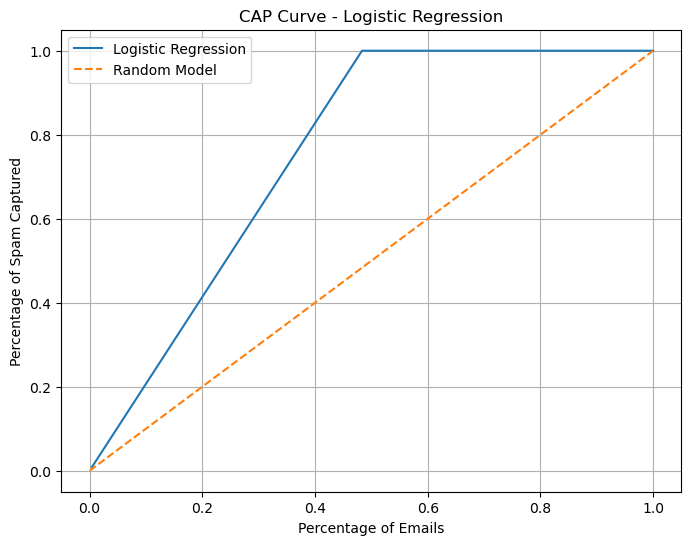

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Get probability of spam (class 1)
y_proba = model.predict_proba(X_test_encoded)[:, 1]

# Sort emails by predicted probability of being spam
order = np.argsort(y_proba)[::-1]

y_test_sorted = y_test_encoded[order]

# Cumulative number of actual spam emails
cum_spam = np.cumsum(y_test_sorted)

# Total number of spam emails
total_spam = np.sum(y_test_sorted)

# Cumulative percentage of actual spam captured
cap_y = cum_spam / total_spam

# Percentage of population contacted
cap_x = np.arange(1, len(y_test_sorted) + 1) / len(y_test_sorted)

# Plot CAP curve
plt.figure(figsize=(8, 6))

plt.plot(cap_x, cap_y, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("Percentage of Emails")
plt.ylabel("Percentage of Spam Captured")
plt.title("CAP Curve - Logistic Regression")
plt.legend()
plt.grid()

plt.show()